# Netflix 롱런 예측 데모

이번 스터디에서는 1회차에서 만든 SQL feature/label 흐름을 이어서, Netflix Top10 콘텐츠의 롱런 여부를 예측하는 데모를 실행하고 결과를 해석합니다.

## 이번 시간에 볼 질문

1. 첫 Top10 진입 주차에 알 수 있는 정보만으로 롱런 여부를 예측할 수 있을까?
2. `weeks_in_top10`, `max_cumulative_weeks`처럼 정답과 가까운 컬럼을 넣으면 성능은 어떻게 달라질까?
3. 단순 baseline과 RandomForest 결과를 어떤 지표로 비교해야 할까?
4. Precision과 Recall 중 어떤 지표를 더 중요하게 볼지는 어떤 운영 비용에 따라 달라질까?
5. 모델 점수를 대시보드나 후속 의사결정 테이블로 넘기려면 어떤 형태가 필요할까?

## 데이터 흐름

이번 노트북은 코드를 직접 빈칸 채우기보다, 준비된 데모 결과를 보고 판단하는 데 초점을 둡니다.

```text
raw Netflix tables
  -> SQL feature engineering
  -> model input table
  -> model evaluation
  -> dashboard output example
```

| 단계 | 역할 |
| --- | --- |
| raw | `netflix_all_weeks_global`, `netflix_titles` |
| intermediate | 콘텐츠-주차 단위 정리, 첫 진입 주차 추출 |
| model input | `netflix_model_input_safe`, `netflix_model_input_leakage` |
| output | 콘텐츠별 롱런 확률과 예측 label |

예측 시점은 **Top10 첫 진입 주차**로 고정합니다. 실제 운영에서는 시간 기준 split으로 과거를 학습하고 미래를 평가하는 편이 자연스럽지만, 여기서는 데모를 단순하게 보기 위해 stratified random split을 사용합니다.

## 핵심 용어 리캡

| 용어 | 이번 노트북에서의 의미 |
| --- | --- |
| classification | `long_run_flag`가 1인지 0인지 맞히는 분류 문제 |
| target / label | 모델이 맞혀야 하는 정답 컬럼, 여기서는 `long_run_flag` |
| feature | 예측에 사용하는 입력 컬럼 |
| positive class | 관심 있는 class, 여기서는 롱런 콘텐츠 `long_run_flag = 1` |
| leakage | 예측 시점에는 알 수 없는 정보가 feature에 섞이는 문제 |
| threshold | 예측 확률을 0/1 label로 바꾸는 기준값 |
| accuracy | 전체 예측 중 맞힌 비율 |
| precision | 롱런이라고 예측한 콘텐츠 중 실제 롱런 비율 |
| recall | 실제 롱런 콘텐츠 중 모델이 잡아낸 비율 |
| F1 | precision과 recall의 균형 지표 |
| ROC-AUC | threshold가 바뀌어도 롱런 콘텐츠를 위로 잘 정렬하는지 보는 지표 |
| confusion matrix | TN, FP, FN, TP를 한 번에 보는 표 |
| cross validation | train data를 여러 번 나눠 성능을 더 안정적으로 보는 검증 방식 |

## 1. 환경 설정

필요한 라이브러리를 불러오고, 숫자와 한글이 읽기 좋게 보이도록 기본 설정을 맞춥니다.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager, rcParams
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.3f}".format

In [2]:
# 한글 그래프 제목/축 라벨이 깨지지 않도록 가능한 폰트를 순서대로 찾는다.
font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font_name in font_candidates:
    if font_name in available_fonts:
        rcParams["font.family"] = font_name
        break

rcParams["axes.unicode_minus"] = False

## 2. 데이터 로딩

기본 흐름은 DB의 model input table을 가져오는 것입니다. DB 연결이 안 되는 환경에서도 같은 노트북을 볼 수 있도록 CSV fallback을 둡니다.

In [3]:
root_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in root_candidates if (path / "week4").exists()), Path.cwd())
DATA_DIR = PROJECT_ROOT / "week4" / "data"

SAFE_CSV = DATA_DIR / "netflix_model_input_safe.csv"
LEAKAGE_CSV = DATA_DIR / "netflix_model_input_leakage.csv"
DB_CONNINFO = "host=localhost port=5432 dbname=dataschool_study user=postgres password=postgres"

In [4]:
def read_table_from_postgres(table_name):
    # PostgreSQL table을 DataFrame으로 읽는다.
    # 이번 스터디의 primary 흐름은 SQL table -> Python model input이다.
    # 그래서 가능하면 DB에서 직접 읽고, 실패할 때만 CSV를 사용한다.
    import psycopg
    from psycopg import sql

    allowed_tables = {
        "netflix_model_input_safe",
        "netflix_model_input_leakage",
    }
    if table_name not in allowed_tables:
        raise ValueError(f"Unexpected table name: {table_name}")

    query = sql.SQL("SELECT * FROM {}").format(sql.Identifier(table_name))

    with psycopg.connect(DB_CONNINFO) as connection:
        with connection.cursor() as cursor:
            cursor.execute(query)
            rows = cursor.fetchall()
            description = cursor.description

    if description is None:
        raise ValueError(f"No result columns returned from table: {table_name}")

    columns = [column.name for column in description]
    return pd.DataFrame(rows, columns=columns)


def load_model_input(table_name, csv_path):
    # DB 우선, CSV fallback 순서로 model input을 읽는다.
    try:
        df = read_table_from_postgres(table_name)
        source = f"db:{table_name}"
    except Exception as exc:
        df = pd.read_csv(csv_path, parse_dates=["first_week_date"])
        source = f"csv:{csv_path.name} (DB fallback: {type(exc).__name__})"

    df["first_week_date"] = pd.to_datetime(df["first_week_date"])
    return df, source


In [5]:
safe_df, safe_source = load_model_input("netflix_model_input_safe", SAFE_CSV)
leakage_df, leakage_source = load_model_input("netflix_model_input_leakage", LEAKAGE_CSV)

safe_source, leakage_source, safe_df.shape, leakage_df.shape

('db:netflix_model_input_safe',
 'db:netflix_model_input_leakage',
 (333, 12),
 (333, 15))

### 로딩 결과 리캡

- `db:...`로 나오면 SQL table에서 직접 읽은 것입니다.
- `csv:...`로 나오면 DB 연결이 안 되어 CSV 백업을 읽은 것입니다.
- 두 경우 모두 같은 schema를 사용하므로 뒤 모델링 흐름은 동일합니다.

In [6]:
# safe table의 앞부분을 보면서 한 행이 어떤 콘텐츠를 뜻하는지 확인한다.
safe_df.head()

,title_clean,show_title,type_clean,primary_genre,first_week_date,first_season,first_month_num,first_week_rank,first_week_hours_viewed,initial_rank_bucket,initial_hours_bucket,long_run_flag
0,married at first sight,Married at First Sight,TV Show,Reality TV,2022-04-24,spring,4,9,12810000,rank_8_10,medium,0
1,she,She,TV Show,Crime TV Shows,2022-06-26,summer,6,7,9490000,rank_4_7,low,0
2,too hot to handle: brazil,Too Hot to Handle: Brazil,TV Show,International TV Shows,2021-07-25,summer,7,6,9450000,rank_4_7,low,0
3,sweet magnolias,Sweet Magnolias,TV Show,Romantic TV Shows,2022-02-06,winter,2,5,43000000,rank_4_7,medium,1
4,triple frontier,Triple Frontier,Movie,Action & Adventure,2023-11-26,fall,11,6,7500000,rank_4_7,low,0


## 3. Safe table과 Leakage table 비교

Safe table은 첫 진입 주차에 알 수 있는 feature만 둡니다. Leakage table은 비교를 위해 사후에만 알 수 있는 `weeks_in_top10`, `best_rank`, `max_cumulative_weeks`를 포함합니다.

### 3-1. 행 수와 target 비율 확인

먼저 두 테이블의 행 수, 콘텐츠 수, 롱런 비율이 같은지 확인합니다. 두 테이블의 차이는 feature 컬럼이어야지, 분석 대상 자체가 달라지면 비교가 흔들립니다.

In [7]:
summary = pd.DataFrame({
    "table": ["safe", "leakage"],
    "rows": [len(safe_df), len(leakage_df)],
    "unique_titles": [safe_df["title_clean"].nunique(), leakage_df["title_clean"].nunique()],
    "long_run_rate": [safe_df["long_run_flag"].mean(), leakage_df["long_run_flag"].mean()],
})
summary

,table,rows,unique_titles,long_run_rate
0,safe,333,333,0.294
1,leakage,333,333,0.294


### 3-2. Leakage table에만 있는 컬럼 확인

아래 3개 컬럼은 콘텐츠가 Top10에 머문 전체 기간을 본 뒤에야 알 수 있습니다. 첫 진입 주차 기준 예측에서는 safe feature로 쓰면 안 됩니다.

In [8]:
leakage_only_columns = sorted(set(leakage_df.columns) - set(safe_df.columns))
leakage_only_columns

['best_rank', 'max_cumulative_weeks', 'weeks_in_top10']

### 3-3. Target 분포 확인

롱런 콘텐츠가 전체의 몇 %인지 확인합니다. positive class가 적으면 Accuracy만으로 모델을 평가하기 어렵습니다.

In [9]:
safe_df["long_run_flag"].value_counts(normalize=True).rename("ratio").to_frame()

,ratio
long_run_flag,
0,0.706
1,0.294


### 데이터 확인 리캡

- 분석 대상은 333개 콘텐츠입니다.
- 롱런 콘텐츠 비율은 약 29%입니다.
- 따라서 무조건 비롱런이라고 찍어도 Accuracy는 어느 정도 나올 수 있습니다.
- 그래서 이후에는 Accuracy뿐 아니라 Precision, Recall, F1, ROC-AUC를 함께 봅니다.

## 4. 롱런과 feature의 관계 먼저 보기

예측 모델을 만들기 전에, safe feature와 `long_run_flag`가 어떤 관계를 보이는지 간단히 확인합니다.

여기서 조심할 점은 “영향을 줬다”라고 단정하지 않는 것입니다. 이 단계에서는 **롱런 콘텐츠와 비롱런 콘텐츠가 어떤 feature에서 차이를 보이는지**를 보는 정도로 해석합니다.

### 4-1. 숫자형 feature와 롱런 여부의 상관관계

숫자형 feature는 `corr()`로 `long_run_flag`와의 상관계수를 간단히 볼 수 있습니다.

해석할 때 주의할 점이 있습니다. `first_week_rank`는 숫자가 작을수록 좋은 순위입니다. 따라서 `first_week_rank`와 `long_run_flag`가 음의 상관관계를 보이면, 첫 진입 순위가 좋을수록 롱런과 관련이 있다는 뜻으로 읽을 수 있습니다.

In [10]:
numeric_feature_cols = [
    "first_month_num",
    "first_week_rank",
    "first_week_hours_viewed",
    "long_run_flag",
]

numeric_corr = safe_df[numeric_feature_cols].corr()
numeric_corr

,first_month_num,first_week_rank,first_week_hours_viewed,long_run_flag
first_month_num,1.000,-0.013,-0.123,0.021
first_week_rank,-0.013,1.000,-0.531,-0.408
first_week_hours_viewed,-0.123,-0.531,1.000,0.475
long_run_flag,0.021,-0.408,0.475,1.000


In [11]:
# long_run_flag와의 상관계수만 따로 꺼내서 크기 순으로 본다.
# 값이 1에 가까우면 같이 증가하는 경향, -1에 가까우면 반대로 움직이는 경향이다.
# 0에 가까우면 선형 관계가 약하다고 본다.
long_run_corr = (
    numeric_corr["long_run_flag"]
    .drop("long_run_flag")
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .to_frame("corr_with_long_run_flag")
)
long_run_corr

,corr_with_long_run_flag
first_week_hours_viewed,0.475
first_week_rank,-0.408
first_month_num,0.021


### 숫자형 상관관계 리캡

상관계수는 숫자형 feature의 선형 관계를 빠르게 보는 도구입니다.

다만 여기서도 인과를 말하면 안 됩니다. 예를 들어 첫 주 시청시간과 롱런 여부가 양의 상관을 보여도, 시청시간이 롱런을 만들었다기보다 이미 관심이 큰 콘텐츠가 오래 머무는 패턴일 수 있습니다.

범주형 feature인 장르, 콘텐츠 유형, 계절은 `corr()`보다 그룹별 롱런 비율로 보는 편이 더 직관적입니다.

### 4-2. 콘텐츠 유형별 롱런 비율

TV Show와 Movie의 롱런 비율이 다른지 확인합니다. 비율과 표본 수를 함께 봐야 합니다.

In [12]:
def summarize_long_run_rate(df, group_col, min_count=5):
    # group_col별 콘텐츠 수와 롱런 비율을 계산한다.
    # 표본 수가 너무 작은 그룹은 비율이 흔들릴 수 있으므로 min_count 이상만 본다.
    summary = (
        df.groupby(group_col)
        .agg(
            content_count=("title_clean", "count"),
            long_run_rate=("long_run_flag", "mean"),
        )
        .query("content_count >= @min_count")
        .sort_values(["long_run_rate", "content_count"], ascending=[False, False])
    )
    return summary


type_long_run = summarize_long_run_rate(safe_df, "type_clean")
type_long_run

,content_count,long_run_rate
type_clean,,
TV Show,167,0.383
Movie,166,0.205


### 4-3. 대표 장르별 롱런 비율

장르는 종류가 많으므로 표본 수가 너무 적은 장르는 제외하고 봅니다. 이 결과는 “어떤 장르가 원인이다”가 아니라, **어떤 장르에서 롱런 비율이 높게 관찰되는지**를 보는 용도입니다.

In [13]:
genre_long_run = summarize_long_run_rate(safe_df, "primary_genre", min_count=8)
genre_long_run.head(15)

,content_count,long_run_rate
primary_genre,,
Romantic TV Shows,9,0.778
TV Action & Adventure,12,0.667
British TV Shows,15,0.400
Crime TV Shows,38,0.395
Kids' TV,8,0.375
Children & Family Movies,29,0.310
International TV Shows,39,0.308
Anime Series,10,0.300
Horror Movies,11,0.273


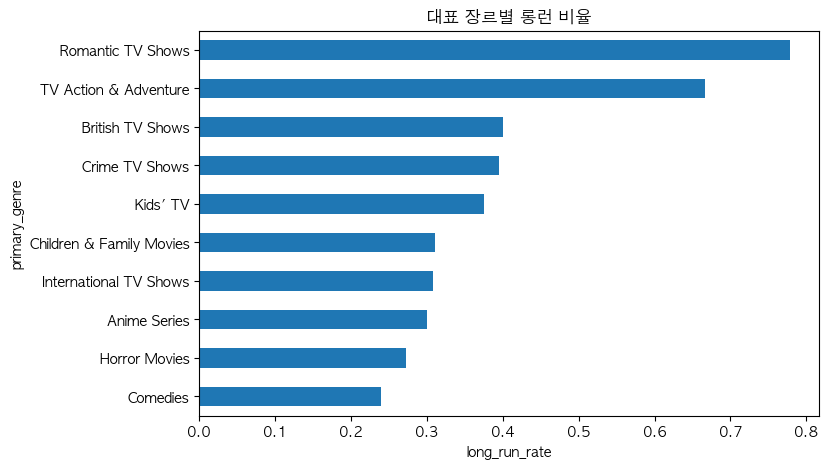

In [14]:
genre_long_run.head(10).sort_values("long_run_rate").plot(
    kind="barh",
    y="long_run_rate",
    figsize=(8, 5),
    legend=False,
)
plt.xlabel("long_run_rate")
plt.ylabel("primary_genre")
plt.title("대표 장르별 롱런 비율")
plt.show()

### 4-4. 첫 진입 순위와 롱런 여부

`first_week_rank`는 숫자가 작을수록 순위가 높습니다. 아래에서는 롱런/비롱런 그룹의 첫 진입 순위 평균을 비교합니다.

In [15]:
rank_summary = (
    safe_df.groupby("long_run_flag")
    .agg(
        content_count=("title_clean", "count"),
        avg_first_week_rank=("first_week_rank", "mean"),
        median_first_week_rank=("first_week_rank", "median"),
        avg_first_week_hours=("first_week_hours_viewed", "mean"),
        median_first_week_hours=("first_week_hours_viewed", "median"),
    )
)
rank_summary

,content_count,avg_first_week_rank,median_first_week_rank,avg_first_week_hours,median_first_week_hours
long_run_flag,,,,,
0,235,6.455,7.000,"11,990,468.085","10,120,000.000"
1,98,3.827,3.000,"42,510,204.082","26,295,000.000"


### 4-5. 첫 주 시청시간 bucket별 롱런 비율

첫 주 시청시간을 `low`, `medium`, `high` bucket으로 나눠 롱런 비율을 봅니다. 이 역시 인과가 아니라 관계 확인입니다.

In [16]:
hours_bucket_summary = summarize_long_run_rate(safe_df, "initial_hours_bucket")
hours_bucket_summary

,content_count,long_run_rate
initial_hours_bucket,,
high,31,0.935
medium,164,0.280
low,138,0.167


### EDA 리캡

이 구간에서 할 수 있는 말은 다음 정도입니다.

- 특정 콘텐츠 유형이나 장르에서 롱런 비율이 더 높게 관찰될 수 있다.
- 첫 진입 순위나 첫 주 시청시간은 롱런 여부와 관련이 있어 보일 수 있다.
- 다만 이것만으로 “이 feature가 롱런을 만들었다”고 말할 수는 없다.

다음 단계의 예측 모델은 이런 feature들을 함께 사용했을 때 롱런 여부를 얼마나 잘 맞히는지 확인하는 과정입니다.

## 5. Feature 선택

모델에 넣을 컬럼과 빼야 할 컬럼을 먼저 정합니다. 이 단계에서 식별자와 정답 컬럼이 feature에 섞이지 않게 하는 것이 중요합니다.

In [17]:
# TARGET_COL은 모델이 맞혀야 하는 정답이다.
# feature에 포함하면 모델이 답을 보고 학습하는 것과 같으므로 반드시 제외한다.
TARGET_COL = "long_run_flag"

# ID_COLS는 콘텐츠를 식별하거나 결과를 보여줄 때 쓰는 컬럼이다.
# title이나 날짜 자체를 그대로 모델에 넣기보다, month/season/rank 같은 feature를 따로 사용한다.
ID_COLS = ["title_clean", "show_title", "first_week_date"]


def make_feature_columns(df):
    # 식별자와 target을 제외한 feature 후보 컬럼을 만든다.
    return [col for col in df.columns if col not in ID_COLS + [TARGET_COL]]


safe_features = make_feature_columns(safe_df)
leakage_features = make_feature_columns(leakage_df)

safe_features, leakage_features

(['type_clean',
  'primary_genre',
  'first_season',
  'first_month_num',
  'first_week_rank',
  'first_week_hours_viewed',
  'initial_rank_bucket',
  'initial_hours_bucket'],
 ['type_clean',
  'primary_genre',
  'first_season',
  'first_month_num',
  'first_week_rank',
  'first_week_hours_viewed',
  'initial_rank_bucket',
  'initial_hours_bucket',
  'weeks_in_top10',
  'best_rank',
  'max_cumulative_weeks'])

## 6. 전처리와 검증용 split

범주형 feature와 숫자형 feature는 처리 방식이 다릅니다. 전처리와 모델을 Pipeline으로 묶으면 train/test 처리 순서를 일관되게 유지할 수 있습니다.

범주형 feature는 문자열 그대로 모델에 넣기 어렵습니다. 예를 들어 `type_clean = TV Show`, `primary_genre = Dramas` 같은 값은 숫자가 아니므로, `OneHotEncoder`로 0/1 컬럼으로 바꿉니다.

```text
type_clean = TV Show
-> type_clean_TV Show = 1
-> type_clean_Movie   = 0
```

숫자형 feature는 scale 차이가 크므로 `StandardScaler`로 크기를 맞춥니다.

여기서 첫 번째 검증 구조를 만듭니다.

```text
전체 데이터
  -> train data: 모델 학습용
  -> test data : 마지막 성능 확인용
```

`stratify=y`를 사용해 train/test 양쪽에 롱런/비롱런 비율이 비슷하게 유지되도록 합니다.


In [18]:
def make_one_hot_encoder():
    # One-Hot Encoding은 범주형 문자열을 모델이 읽을 수 있는 0/1 컬럼으로 바꾸는 전처리다.
    # 예: type_clean이 Movie/TV Show라면 각각 별도 컬럼을 만들고 해당하면 1, 아니면 0으로 표시한다.
    # handle_unknown="ignore"는 test data에 train data에서 못 본 category가 나와도 에러를 내지 않게 한다.
    # scikit-learn 버전에 따라 OneHotEncoder 인자가 조금 달라질 수 있어 안전하게 처리한다.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(X):
    # 컬럼 타입에 따라 서로 다른 전처리를 적용한다.
    # - categorical: 문자열/범주형 컬럼을 One-Hot Encoding한다.
    # - numeric: 숫자형 컬럼을 StandardScaler로 스케일링한다.
    # - ColumnTransformer는 컬럼 묶음별 전처리를 하나로 합쳐주는 도구다.
    categorical_cols = X.select_dtypes(include=["object", "category", "str"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            # 범주형 feature는 OneHotEncoder로 category별 0/1 컬럼을 만든다.
            ("categorical", make_one_hot_encoder(), categorical_cols),
            # 숫자형 feature는 평균 0, 표준편차 1에 가깝게 스케일을 맞춘다.
            ("numeric", StandardScaler(), numeric_cols),
        ],
        remainder="drop",
    )


def make_pipeline(model, X):
    # 전처리와 모델을 하나의 Pipeline으로 묶는다.
    # Pipeline을 쓰면 train data에 fit한 전처리를 test data에는 transform만 적용할 수 있다.
    # 이런 구조는 train/test 사이의 전처리 leakage를 줄이는 데 도움이 된다.
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(X)),
            ("model", model),
        ]
    )


In [19]:
def split_data(df, feature_cols):
    # train/test 데이터를 나눈다.
    # train data는 모델 학습에 사용하고, test data는 마지막 성능 확인에 사용한다.
    # stratify=y를 사용하면 train/test에 long_run_flag 비율이 비슷하게 유지된다.
    # 데이터가 작고 positive class가 적을 때는 이 설정이 특히 중요하다.
    X = df[feature_cols].copy()
    y = df[TARGET_COL].astype(int)
    return train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )


X_train_safe, X_test_safe, y_train_safe, y_test_safe = split_data(safe_df, safe_features)
X_train_leak, X_test_leak, y_train_leak, y_test_leak = split_data(leakage_df, leakage_features)

split_summary = pd.DataFrame({
    "dataset": ["train_safe", "test_safe"],
    "role": ["model fit", "final evaluation"],
    "rows": [len(X_train_safe), len(X_test_safe)],
    "long_run_count": [int(y_train_safe.sum()), int(y_test_safe.sum())],
    "long_run_rate": [y_train_safe.mean(), y_test_safe.mean()],
})
split_summary


,dataset,role,rows,long_run_count,long_run_rate
0,train_safe,model fit,249,73,0.293
1,test_safe,final evaluation,84,25,0.298


### Split 리캡

이 노트북의 기본 검증은 train/test split입니다.

- train data: 모델이 학습할 때 보는 데이터
- test data: 학습이 끝난 뒤 마지막으로 성능을 확인하는 데이터

`long_run_rate`가 train/test에서 비슷하면 `stratify=y`가 의도대로 작동한 것입니다. 실제 운영에서는 시간 흐름 데이터 특성상 과거 기간으로 학습하고 미래 기간으로 평가하는 time-based split도 고려해야 합니다.

## 7. 평가 함수

모델마다 같은 기준으로 비교할 수 있도록 평가 함수를 하나로 고정합니다.

In [20]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    # 모델을 학습하고 주요 분류 지표를 계산한다.
    # 지표 해석:
    # - accuracy: 전체 중 맞힌 비율
    # - precision: 롱런이라고 예측한 것 중 실제 롱런 비율
    # - recall: 실제 롱런 중 모델이 잡아낸 비율
    # - f1: precision과 recall의 균형
    # - roc_auc: threshold를 바꾸더라도 positive를 위로 정렬하는 능력
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    prediction = pd.DataFrame(
        {
            "actual": y_test,
            "predicted": y_pred,
            "long_run_probability": y_prob,
        },
        index=y_test.index,
    )
    return metrics, prediction, pipeline

## 8. Leakage 포함 모델과 Safe 모델 비교

먼저 같은 LogisticRegression을 사용해 leakage feature가 들어간 경우와 safe feature만 쓴 경우를 비교합니다. 성능 차이가 크다면 “좋은 모델”이라기보다 예측 시점 이후의 정보가 들어갔는지 먼저 의심해야 합니다.

In [21]:
baseline_model = LogisticRegression(max_iter=1_000, class_weight="balanced")

safe_baseline_metrics, safe_baseline_pred, safe_baseline_pipeline = evaluate_model(
    "LogisticRegression_safe",
    make_pipeline(baseline_model, X_train_safe),
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe,
)

leakage_baseline_metrics, leakage_baseline_pred, leakage_baseline_pipeline = evaluate_model(
    "LogisticRegression_leakage",
    make_pipeline(LogisticRegression(max_iter=1_000, class_weight="balanced"), X_train_leak),
    X_train_leak,
    X_test_leak,
    y_train_leak,
    y_test_leak,
)

pd.DataFrame([safe_baseline_metrics, leakage_baseline_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression_safe,0.738,0.548,0.680,0.607,0.798
1,LogisticRegression_leakage,0.952,0.957,0.880,0.917,0.986


### Leakage 비교 리캡

실행 결과에서 leakage 모델은 safe 모델보다 성능이 훨씬 높게 나옵니다. 하지만 이 성능은 신뢰하기 어렵습니다.

이유는 leakage table에 들어간 `weeks_in_top10`, `best_rank`, `max_cumulative_weeks`가 콘텐츠의 전체 Top10 기간을 본 뒤에야 알 수 있는 값이기 때문입니다. 특히 `max_cumulative_weeks`는 `long_run_flag`를 만드는 기준과 직접 연결되어 있습니다.

따라서 여기서 배울 점은 “leakage를 넣으면 성능이 잘 나온다”가 아니라, **성능이 너무 좋아 보이면 먼저 feature가 예측 시점에 사용 가능한지 확인해야 한다**입니다.

## 9. Baseline 해석

`LogisticRegression`은 이름에 Regression이 있지만, 여기서는 0/1 label을 예측하는 분류 baseline입니다. baseline은 복잡한 모델을 쓰기 전에 “이 정도는 넘어야 한다”는 비교 기준입니다.

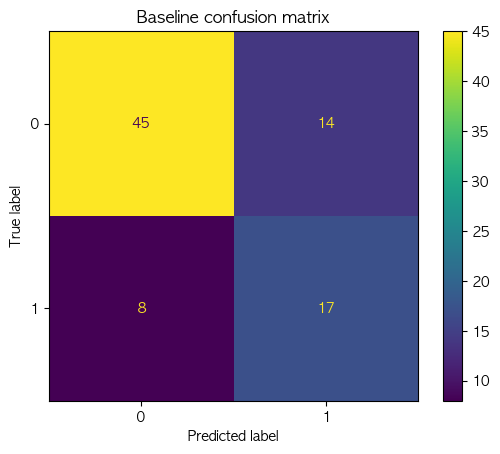

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test_safe, safe_baseline_pred["predicted"])
plt.title("Baseline confusion matrix")
plt.show()

In [23]:
# confusion matrix를 숫자로도 확인한다.
# TN: 비롱런을 비롱런으로 맞힘
# FP: 비롱런을 롱런으로 잘못 예측
# FN: 롱런을 놓침
# TP: 롱런을 롱런으로 맞힘
baseline_tn, baseline_fp, baseline_fn, baseline_tp = confusion_matrix(
    y_test_safe,
    safe_baseline_pred["predicted"],
).ravel()

pd.DataFrame([{
    "tn": baseline_tn,
    "fp": baseline_fp,
    "fn": baseline_fn,
    "tp": baseline_tp,
}])

,tn,fp,fn,tp
0,45,14,8,17


### Baseline 리캡

현재 safe baseline은 실제 롱런 콘텐츠를 비교적 넓게 잡는 편입니다. Recall이 상대적으로 높다는 것은 “실제 롱런 중 놓치지 않고 잡아낸 비율”이 괜찮다는 뜻입니다.

반대로 False Positive도 생깁니다. 즉 롱런이 아닌 콘텐츠를 롱런 후보로 잘못 올릴 수 있습니다. 마케팅 후보 발굴처럼 넓게 잡는 용도라면 괜찮을 수 있지만, 비용이 큰 운영 결정이라면 Precision을 더 봐야 합니다.

## 10. RandomForest로 모델 교체

테이블 데이터는 숫자형/범주형 feature가 섞이고, 특정 threshold에서 결과가 달라지는 경우가 많습니다. 트리 모델은 `first_week_rank <= 3`, `type_clean = TV Show` 같은 조건 분기를 자연스럽게 학습할 수 있습니다.

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)

rf_metrics, rf_pred, rf_pipeline = evaluate_model(
    "RandomForest_safe",
    make_pipeline(rf_model, X_train_safe),
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe,
)

pd.DataFrame([safe_baseline_metrics, rf_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression_safe,0.738,0.548,0.680,0.607,0.798
1,RandomForest_safe,0.774,0.714,0.400,0.513,0.804


### RandomForest 리캡

기본 RandomForest는 baseline보다 더 보수적으로 예측하는 경향이 있습니다. Precision은 올라가지만 Recall은 낮아질 수 있습니다.

이 말은 “롱런이라고 찍은 콘텐츠는 더 믿을 만하지만, 실제 롱런 콘텐츠를 더 많이 놓칠 수 있다”는 뜻입니다. 따라서 모델 교체 후에는 Accuracy 하나만 보지 말고 Precision과 Recall의 방향을 함께 봐야 합니다.

### 10-1. RandomForest feature importance 확인

트리 모델은 feature importance를 제공합니다. 다만 이것은 인과 효과가 아니라, **이 모델이 예측에 자주 사용한 feature**에 가깝습니다.

In [25]:
def get_feature_names_from_pipeline(pipeline):
    # ColumnTransformer가 만든 최종 feature 이름을 가져온다.
    # One-Hot Encoding된 범주형 컬럼은 원래 컬럼명과 category 값이 함께 표시된다.
    preprocessor = pipeline.named_steps["preprocess"]
    return preprocessor.get_feature_names_out()


rf_feature_importance = pd.DataFrame({
    "feature": get_feature_names_from_pipeline(rf_pipeline),
    "importance": rf_pipeline.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

rf_feature_importance.head(15)

,feature,importance
276,numeric__first_week_rank,0.115
275,numeric__first_month_num,0.069
271,categorical__initial_rank_bucket_top_3,0.057
272,categorical__initial_hours_bucket_high,0.035
270,categorical__initial_rank_bucket_rank_8_10,0.028
269,categorical__initial_rank_bucket_rank_4_7,0.023
273,categorical__initial_hours_bucket_low,0.022
274,categorical__initial_hours_bucket_medium,0.021
25,categorical__first_season_fall,0.020
1,categorical__type_clean_TV Show,0.018


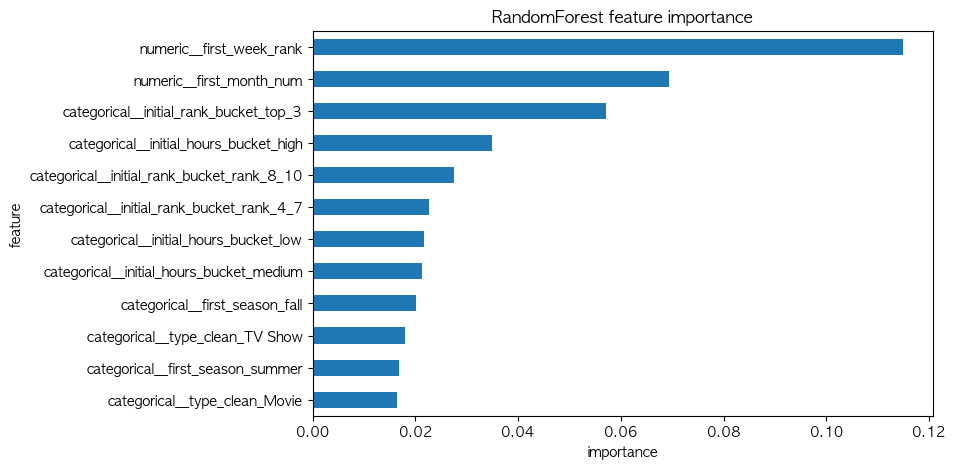

In [26]:
rf_feature_importance.head(12).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 5),
    legend=False,
)
plt.xlabel("importance")
plt.ylabel("feature")
plt.title("RandomForest feature importance")
plt.show()

### Feature importance 리캡

Feature importance가 높다는 것은 모델이 해당 feature를 예측에 많이 사용했다는 뜻입니다.

하지만 이것을 “롱런의 원인”이라고 해석하면 안 됩니다. 예를 들어 첫 주 시청시간이 중요하게 나와도, 시청시간이 롱런을 만들었다기보다 이미 인기가 높은 콘텐츠가 더 오래 머무는 패턴일 수 있습니다.

## 11. RandomizedSearchCV와 3-fold cross validation

튜닝은 모델을 바꾸는 마법이 아니라, 정해둔 탐색 범위 안에서 더 나은 조합을 찾아보는 절차입니다.

여기서 두 번째 검증 구조가 등장합니다.

```text
train data
  -> 3-fold cross validation으로 여러 조합 비교
  -> 가장 나은 조합 선택
  -> 선택된 모델을 test data에서 최종 평가
```

중요한 점은 `cv=3`이 test data를 쓰는 것이 아니라, train data 내부를 다시 나눠서 튜닝 안정성을 높이는 장치라는 점입니다.

In [27]:
search_pipeline = make_pipeline(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    X_train_safe,
)

# RandomizedSearchCV는 모든 조합을 전부 보지 않고, 후보 조합 중 일부를 샘플링해 탐색한다.
# cv=3은 train data를 3개 fold로 나눠 검증한다는 뜻이다.
# 여기서는 데모 속도를 위해 n_iter를 작게 둔다.
param_distributions = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 3, 5, 8],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train_safe, y_train_safe)

pd.DataFrame([{
    "cv_folds": search.cv,
    "scoring": search.scoring,
    "best_cv_f1": search.best_score_,
    "best_params": search.best_params_,
}])


,cv_folds,scoring,best_cv_f1,best_params
0,3,f1,0.593,"{'model__n_estimators': 200, 'model__min_sampl..."


In [28]:
best_rf_metrics, best_rf_pred, best_rf_pipeline = evaluate_model(
    "RandomForest_randomized_search",
    search.best_estimator_,
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe,
)

pd.DataFrame([safe_baseline_metrics, rf_metrics, best_rf_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression_safe,0.738,0.548,0.680,0.607,0.798
1,RandomForest_safe,0.774,0.714,0.400,0.513,0.804
2,RandomForest_randomized_search,0.750,0.583,0.560,0.571,0.849


### 모델 비교 리캡

위 표는 같은 test data에서 세 모델을 비교한 결과입니다.

- `LogisticRegression_safe`는 baseline입니다. 단순하지만 롱런 후보를 비교적 넓게 잡는 경향이 있어 Recall을 확인하기 좋습니다.
- `RandomForest_safe`는 기본 트리 앙상블 모델입니다. 표 형태 데이터의 조건 분기를 잘 다루지만, 현재 결과에서는 baseline보다 더 보수적으로 예측해 Precision은 오르고 Recall은 낮아질 수 있습니다.
- `RandomForest_randomized_search`는 train data 안에서 `cv=3`으로 여러 파라미터 조합을 비교한 뒤 선택한 모델입니다. ROC-AUC가 좋아질 수 있지만, threshold 0.5에서 Precision/Recall/F1이 항상 baseline보다 좋아지는 것은 아닙니다.

따라서 이 비교의 핵심은 “튜닝 모델이 무조건 최고”가 아니라, **목적에 따라 어떤 지표를 볼지 정해야 한다**는 점입니다. 롱런 후보를 놓치지 않는 것이 중요하면 Recall을, 후보를 적게 잡더라도 정확도가 중요하면 Precision을 더 봅니다.

### 튜닝 결과 리캡

`RandomizedSearchCV(cv=3)`는 train data 안에서만 3-fold 검증을 수행합니다. 즉 test data는 튜닝 조합을 고르는 데 사용하지 않습니다.

튜닝된 RandomForest는 ROC-AUC가 좋아질 수 있습니다. ROC-AUC가 높다는 것은 콘텐츠를 롱런 가능성이 높은 순서로 정렬하는 능력이 좋아졌다는 뜻입니다.

다만 threshold 0.5에서 Precision, Recall, F1이 항상 baseline보다 좋아지는 것은 아닙니다. 그래서 튜닝 결과를 볼 때는 “cross validation에서 고른 조합”, “test data 최종 성능”, “운영 threshold에서의 0/1 예측 성능”을 구분해서 봐야 합니다.

## 12. Threshold 변경 실험

모델은 확률을 내고, 우리는 threshold를 정해 0/1 예측으로 바꿉니다. threshold를 낮추면 더 많은 콘텐츠를 롱런 후보로 잡아 Recall이 올라갈 수 있지만, False Positive도 늘어날 수 있습니다.

In [29]:
probability = best_rf_pred["long_run_probability"].to_numpy()
actual = best_rf_pred["actual"].to_numpy()

threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    predicted = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(actual, predicted, zero_division=0),
            "recall": recall_score(actual, predicted, zero_division=0),
            "f1": f1_score(actual, predicted, zero_division=0),
            "false_positive": fp,
            "false_negative": fn,
        }
    )

pd.DataFrame(threshold_rows)

,threshold,precision,recall,f1,false_positive,false_negative
0,0.300,0.298,1.000,0.459,59,0
1,0.400,0.312,1.000,0.476,55,0
2,0.500,0.583,0.560,0.571,10,11
3,0.600,1.000,0.280,0.438,0,18
4,0.700,0.000,0.000,0.000,0,25


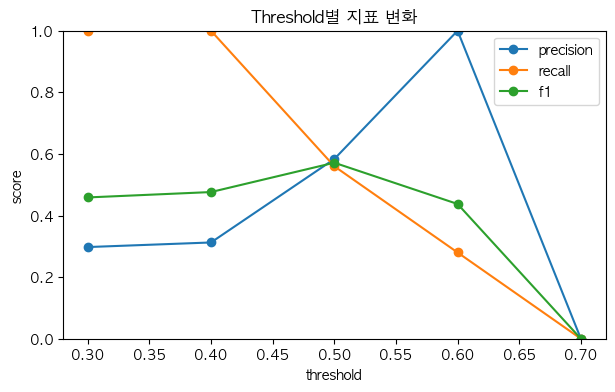

In [30]:
threshold_df = pd.DataFrame(threshold_rows)

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.xlabel("threshold")
plt.ylabel("score")
plt.ylim(0, 1)
plt.legend()
plt.title("Threshold별 지표 변화")
plt.show()

### Threshold 리캡

Threshold는 모델 자체라기보다 운영 정책에 가깝습니다.

- threshold를 낮추면 더 많은 콘텐츠를 롱런 후보로 잡습니다. Recall은 올라가지만 False Positive도 늘어납니다.
- threshold를 높이면 더 확실한 콘텐츠만 롱런으로 잡습니다. Precision은 올라갈 수 있지만 False Negative가 늘어납니다.

따라서 “좋은 threshold”는 데이터만 보고 정해지는 값이 아니라, 롱런 후보를 놓치는 비용과 잘못 추천하는 비용 중 무엇이 더 큰지에 따라 달라집니다.

## 13. 대시보드용 결과 테이블 예시

대시보드나 후속 시스템으로 넘길 때는 모델 내부 객체보다, 콘텐츠별 점수와 예측 label이 들어간 결과 테이블이 필요합니다.

여기서는 `RandomForest_randomized_search` 모델, 즉 `RandomizedSearchCV`로 선택된 RandomForest를 사용합니다. Threshold는 기본값 `0.50`으로 두고, 이 값 이상이면 롱런 후보로 표시합니다.

In [31]:
# 대시보드용 예측은 RandomizedSearchCV로 선택된 best_rf_pipeline 결과를 사용한다.
# threshold 0.50 이상이면 predicted_long_run_flag = 1로 표시한다.
DASHBOARD_THRESHOLD = 0.50

meta_cols = ["title_clean", "show_title", "type_clean", "primary_genre", "first_week_date"]
dashboard_output = safe_df.loc[X_test_safe.index, meta_cols].copy()
dashboard_output["long_run_probability"] = best_rf_pred["long_run_probability"]
dashboard_output["predicted_long_run_flag"] = (
    dashboard_output["long_run_probability"] >= DASHBOARD_THRESHOLD
).astype(int)
dashboard_output["actual_long_run_flag"] = y_test_safe
dashboard_output["model_version"] = "random_forest_randomized_v1"
dashboard_output["threshold"] = DASHBOARD_THRESHOLD

dashboard_output.sort_values("long_run_probability", ascending=False).head(20)


,title_clean,show_title,type_clean,primary_genre,first_week_date,long_run_probability,predicted_long_run_flag,actual_long_run_flag,model_version,threshold
212,sex/life,Sex/Life,TV Show,Romantic TV Shows,2021-07-04,0.636,1,1,random_forest_randomized_v1,0.500
240,virgin river,Virgin River,TV Show,Romantic TV Shows,2021-07-11,0.636,1,1,random_forest_randomized_v1,0.500
31,ozark,Ozark,TV Show,Crime TV Shows,2022-01-23,0.622,1,1,random_forest_randomized_v1,0.500
318,dark desire,Dark Desire,TV Show,Crime TV Shows,2022-02-06,0.617,1,1,random_forest_randomized_v1,0.500
36,cobra kai,Cobra Kai,TV Show,TV Action & Adventure,2022-01-02,0.616,1,1,random_forest_randomized_v1,0.500
66,ginny & georgia,Ginny & Georgia,TV Show,Romantic TV Shows,2023-01-08,0.616,1,1,random_forest_randomized_v1,0.500
92,lost in space,Lost in Space,TV Show,TV Action & Adventure,2021-12-05,0.611,1,1,random_forest_randomized_v1,0.500
131,sweet girl,Sweet Girl,Movie,Action & Adventure,2021-08-22,0.590,1,1,random_forest_randomized_v1,0.500
272,shaman king,SHAMAN KING,TV Show,Anime Series,2021-08-15,0.584,1,0,random_forest_randomized_v1,0.500
292,the queen of flow,The Queen of Flow,TV Show,Crime TV Shows,2021-11-21,0.574,1,1,random_forest_randomized_v1,0.500


### Output table 리캡

이 테이블은 모델 학습용 입력이 아니라, 후속 대시보드나 운영 판단에 넘길 결과물입니다.

이 예시는 `RandomForest_randomized_search` 결과를 사용합니다. 즉 baseline LogisticRegression이 아니라, `RandomizedSearchCV`가 train data 내부 3-fold CV로 고른 RandomForest 모델의 예측 확률입니다.

중요한 컬럼은 다음과 같습니다.

- `long_run_probability`: 모델이 계산한 롱런 가능성 점수
- `predicted_long_run_flag`: threshold를 적용한 최종 예측 label
- `actual_long_run_flag`: 검증용 실제 label
- `model_version`: 어떤 모델 결과인지 추적하기 위한 이름
- `threshold`: 예측 label을 만들 때 사용한 기준값

## 14. HTML 대시보드로 결과 확인

노트북에서 계산한 예측 결과를 비즈니스 관점으로 훑어볼 수 있도록 정적 HTML 대시보드를 함께 제공합니다.

대시보드는 `RandomForest_randomized_search` 모델의 예측 결과를 사용합니다. 화면의 threshold 슬라이더는 같은 예측 확률을 기준으로 롱런 후보 판정 기준만 바꿔보는 장치입니다.

대시보드에서는 콘텐츠 검색, 유형/장르 필터, threshold 조정, KPI, 장르별 평균 확률, 상위 롱런 후보를 확인할 수 있습니다.

In [32]:
from IPython.display import IFrame

IFrame("netflix_longrun_dashboard.html", width="100%", height=820)

## 최종 정리

- 롱런 예측은 유지 주 수를 직접 맞히는 회귀가 아니라, `long_run_flag`를 맞히는 분류 문제로 정의했습니다.
- EDA에서는 롱런 콘텐츠와 비롱런 콘텐츠의 feature 차이를 볼 수 있지만, 이것만으로 인과를 말할 수는 없습니다.
- 기본 검증은 train/test split이며, test data는 최종 성능 확인용으로 남겨둡니다.
- RandomizedSearchCV의 `cv=3`은 train data 내부에서 튜닝 조합을 비교하기 위한 cross validation입니다.
- 첫 진입 주차 기준 예측에서는 사후 성과 지표를 feature로 넣으면 leakage가 됩니다.
- Baseline은 복잡한 모델을 평가하기 위한 기준점입니다.
- RandomForest feature importance는 모델이 예측에 많이 사용한 feature이지, 롱런의 원인을 뜻하지 않습니다.
- RandomForest와 튜닝 결과는 지표만 보지 말고, Precision/Recall과 운영 비용을 함께 봐야 합니다.
- Threshold는 모델 성능 지표가 아니라 운영 정책과 연결됩니다.
- 확률값과 예측 label은 대시보드용 output table로 이어질 수 있습니다.